In [22]:
#load in the dataset
import pandas as pd

df = pd.read_csv('food_ingredients_and_allergens.csv')
df_2 = pd.read_csv('allergen dataset.csv')
df_3 = pd.read_csv('FoodData.csv')


# collapse all labels except class labels into one 'text' feature
#from sklearn.datasets import make_multilabel_classification

#multilabeller needs a set list of labels. i think i should go with the 14 allergens. Some of these allergen names need to be normalised.
allowed = {"celery", "gluten", "crustacean", "eggs", "fish",
           "lupin", "dairy", "mollusc", "mustard", "peanuts",
           "sesame", "soy", "sulphur dioxide", "sulphites", "tree nuts"}

#create a custom dictionary of allergen names
allergen_dict = {

    "ghee" : "dairy",
    "milk" : "dairy",
    "dairy" : "dairy",

    "shellfish" : "crustacean",

    "mustard" : "mustard",

    "soy" : "soy",
    "soybean" : "soy",
    "soybeans" : "soy",

    "tree nut" : "tree nuts",
    "nuts" : "tree nuts",
    "nut" : "tree nuts",
    "almonds" : "tree nuts",
    "walnuts" : "tree nuts",
    "pine nuts" : "tree nuts",

    "fish" : "fish",

    "wheat" : "gluten",
    "gluten" : "gluten",
    
    "celery" : "celery",

    "peanut" : "peanuts",
    "peanuts" : "peanuts",

    "eggs" : "eggs",
    "egg" : "eggs",

    "lupine" : "lupin",

}

def normalise_allergens(allergen_list):
    normalised = set() #from each row, the set of unique allergens
    allergen_list = str(allergen_list)
    #print(allergen_list)
    if( allergen_list.find(",") == True ):
        allergen_list_strip = [a.strip() for a in allergen_list.split(",")]
    else:
        allergen_list_strip = [a.strip() for a in allergen_list.split(" ")]
    #print("allergen_list: ", allergen_list)
    #print(allergen_list_strip)

    for allergen in allergen_list_strip:
        allergen = allergen.lower().strip()
        #print(allergen)

        # Step 1: map synonyms
        if allergen in allergen_dict:
            #print(allergen, "is in dict")
            #print("translation: ", allergen_dict[allergen])
            normalised.add(allergen_dict[allergen]) #translate
            continue

        # Step 2: keep only if already canonical
        if allergen in allowed:
            normalised.add(allergen) #filter
    
    return list(normalised)

x = []
#x = df['Allergens'].apply(normalise_allergens)

df['Allergens'] = df['Allergens'].apply(normalise_allergens)
df_2['allergy'] = df_2['allergy'].apply(normalise_allergens)
df_3['Allergy'] = df_3['Allergy'].apply(normalise_allergens)

#display(df)

#create a new dataframe

data = {
    'Food' : [],
    'Allergens' : []
}

labels = ['Food Product', 'Main Ingredient', 'Sweetener', 'Fat/Oil', 'Seasoning']

for index, row in df.iterrows():
    food_list = ""
    for label in labels:
        if(type(row[str(label)]) == str):
            food_list = food_list + (row[str(label)]) + " "
    data["Food"].append(food_list)
    data["Allergens"].append(row["Allergens"])

for index, row in df_2.iterrows():
    data["Food"].append(row['ingredient'])
    data["Allergens"].append(row["allergy"])

for index, row in df_3.iterrows():
    data["Food"].append(row['Food'])
    data["Allergens"].append(row["Allergy"])

display(pd.DataFrame(data))


,Food,Allergens
0,Almond Cookies Almonds Sugar Butter Flour,[dairy]
1,Almond Cookies Almonds Sugar Butter Flour,[dairy]
2,Chicken Noodle Soup Chicken broth Salt,[celery]
3,Chicken Noodle Soup Chicken broth Salt,[celery]
4,Cheddar Cheese Cheese Salt,[dairy]
...,...,...
1115,Wheat,[gluten]
1116,Whey,[dairy]
1117,White bean,[]
1118,Yam,[]


In [23]:
#encode for multi labelling
from sklearn.preprocessing import MultiLabelBinarizer
import pandas as pd

# Sample multi-label data
y = data["Allergens"]

# Initialize and fit MultiLabelBinarizer
mlb = MultiLabelBinarizer()
y_encoded = mlb.fit_transform(y)

food = data["Food"]

#print(y_encoded)
print(food)
#print(mlb.classes_)
#print(allowed)



['Almond Cookies Almonds Sugar Butter Flour ', 'Almond Cookies Almonds Sugar Butter Flour ', 'Chicken Noodle Soup Chicken broth Salt ', 'Chicken Noodle Soup Chicken broth Salt ', 'Cheddar Cheese Cheese Salt ', 'Ranch Dressing Buttermilk Sugar Vegetable oil Garlic, herbs ', 'Caramel Popcorn Popcorn Sugar Butter Salt ', 'Caesar Salad Romaine lettuce Olive oil Parmesan cheese ', 'Caesar Wrap Grilled chicken Caesar dressing Lettuce, Parmesan cheese ', 'Strawberry Smoothie Strawberries Honey Yogurt (milk, cultures) ', 'Cheese Pizza Cheese Tomato sauce ', 'Margherita Pizza Cheese Tomato sauce, basil ', 'Mashed Potatoes Potatoes Butter Salt, Pepper ', 'Greek Yogurt Yogurt (milk, cultures) ', 'Caesar Salad Wrap Grilled chicken Caesar dressing Lettuce, Parmesan cheese ', 'Caprese Salad Tomatoes Olive oil Mozzarella cheese, basil ', 'Berry Smoothie Mixed berries Sugar Yogurt (milk, cultures) ', 'Caesar Salad Romaine lettuce Olive oil Caesar dressing ', 'Berry Parfait Mixed berries Sugar Yogurt (

In [ ]:
import numpy as np
from sklearn.datasets import make_multilabel_classification
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from skmultilearn.model_selection import iterative_train_test_split
from sklearn.multioutput import MultiOutputClassifier #Using this we can retrofit any classifier to be a multi labeller. 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, hamming_loss, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt

# Apply SMOTE per minority label
# Consider skmultilearn's MLSMOTE for native multi-label support
from skmultilearn.model_selection import iterative_train_test_split

from sklearn.pipeline import Pipeline, FeatureUnion
import random

#Text rep

random.seed(42)

# Word-level TF-IDF
word_tfidf = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9,
    max_features=20000
)

# Character-level TF-IDF (your current one)
char_tfidf = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),
    min_df=2,
    max_df=0.9,
    max_features=20000
)

combined = FeatureUnion([
    ('word', word_tfidf),
    ('char', char_tfidf)
])

#{'clf__estimator__C': 0.5, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (2, 4)}

# initializing TfidfVectorizer 
vetorizar = TfidfVectorizer(
    analyzer='char', 
    ngram_range=(2, 4),      # unigrams + bigrams
    min_df=2,                # ignore very rare terms
    max_df=0.9,              # ignore extremely common terms
    max_features=10000,      # cap vocabulary size
)

# fitting the tf-idf on the given data
#X = vetorizar.fit_transform(food)
#for some reason the original vectoriser works better. No clue as to why
X_combined = vetorizar.fit_transform(food)

#print(X.shape)
print(X_combined.shape)
print(y_encoded.shape)



In [ ]:
#BERT instead of tf idf for text rep

from transformers import AutoTokenizer, AutoModel
import torch

# Use the same DistilBERT model FoodBERT is built on
tokenizer = AutoTokenizer.from_pretrained("chambliss/distilbert-for-food-extraction")
model = AutoModel.from_pretrained("chambliss/distilbert-for-food-extraction")

def get_embedding(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128)
    with torch.no_grad():
        outputs = model(**inputs)
    # Mean pool the token embeddings
    return outputs.last_hidden_state.mean(dim=1).squeeze().numpy()

X = np.array([get_embedding(dish) for dish in food])

In [ ]:

# Splitting the dataset into train and test sets
X_train, y_train, X_test, y_test = iterative_train_test_split(X_combined, y_encoded, test_size=0.2)


#ML model training


base_clf = LogisticRegression(
    max_iter=1000,
    C=0.5,                 # try >1.0 for less regularization
    class_weight='balanced',  # handle label imbalance
    solver='liblinear'     # often good for sparse, small-ish problems
)


# Creating the MultiOutput Classifier with Logistic Regression as the base estimator
classifier = MultiOutputClassifier(base_clf)



(1120, 4855)
(1120, 12)


In [49]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(analyzer='char', ngram_range=(3, 5))),
    ('clf', MultiOutputClassifier(LogisticRegression(max_iter=1000)))
])

param_grid = {
    'tfidf__max_features': [10000, 20000],
    'tfidf__ngram_range': [(2, 4), (3, 5), (2, 5)],
    'clf__estimator__C': [0.5, 1.0, 2.0, 5.0],
}

grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring='f1_micro', n_jobs=-1)
grid_search.fit(food, y_encoded)
print("Best params:", grid_search.best_params_)

c:\Users\enara\anaconda3\envs\ocr\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
24 fits failed out of a total of 72.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
24 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\enara\anaconda3\envs\ocr\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\enara\anaconda3\envs\ocr\lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\enara\anaconda3\envs\ocr\lib\site-packages\sklearn\pipeline.py", line 663, in fit
    self._final_estimator.fit(Xt, y, **last

Best params: {'clf__estimator__C': 0.5, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (2, 4)}


Accuracy: 0.8303571428571429
Hamming loss: 0.016741071428571428
Micro F1: 0.8363636363636363
Macro F1: 0.8143313527636503
Exact Match Ratio:  0.8303571428571429
01 Loss:  0.16964285714285715
Per-label report:
               precision    recall  f1-score   support

      celery       0.88      0.88      0.88         8
  crustacean       0.60      0.86      0.71         7
       dairy       0.90      0.80      0.85        56
        eggs       0.78      1.00      0.88         7
        fish       0.44      1.00      0.62         4
      gluten       0.75      0.69      0.72        13
       lupin       1.00      1.00      1.00         6
     mustard       1.00      0.89      0.94         9
     peanuts       1.00      1.00      1.00         9
      sesame       1.00      0.75      0.86         4
         soy       1.00      0.71      0.83        14
   tree nuts       0.50      0.50      0.50         2

   micro avg       0.85      0.83      0.84       139
   macro avg       0.82      0.8

c:\Users\enara\anaconda3\envs\ocr\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\enara\anaconda3\envs\ocr\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\enara\anaconda3\envs\ocr\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


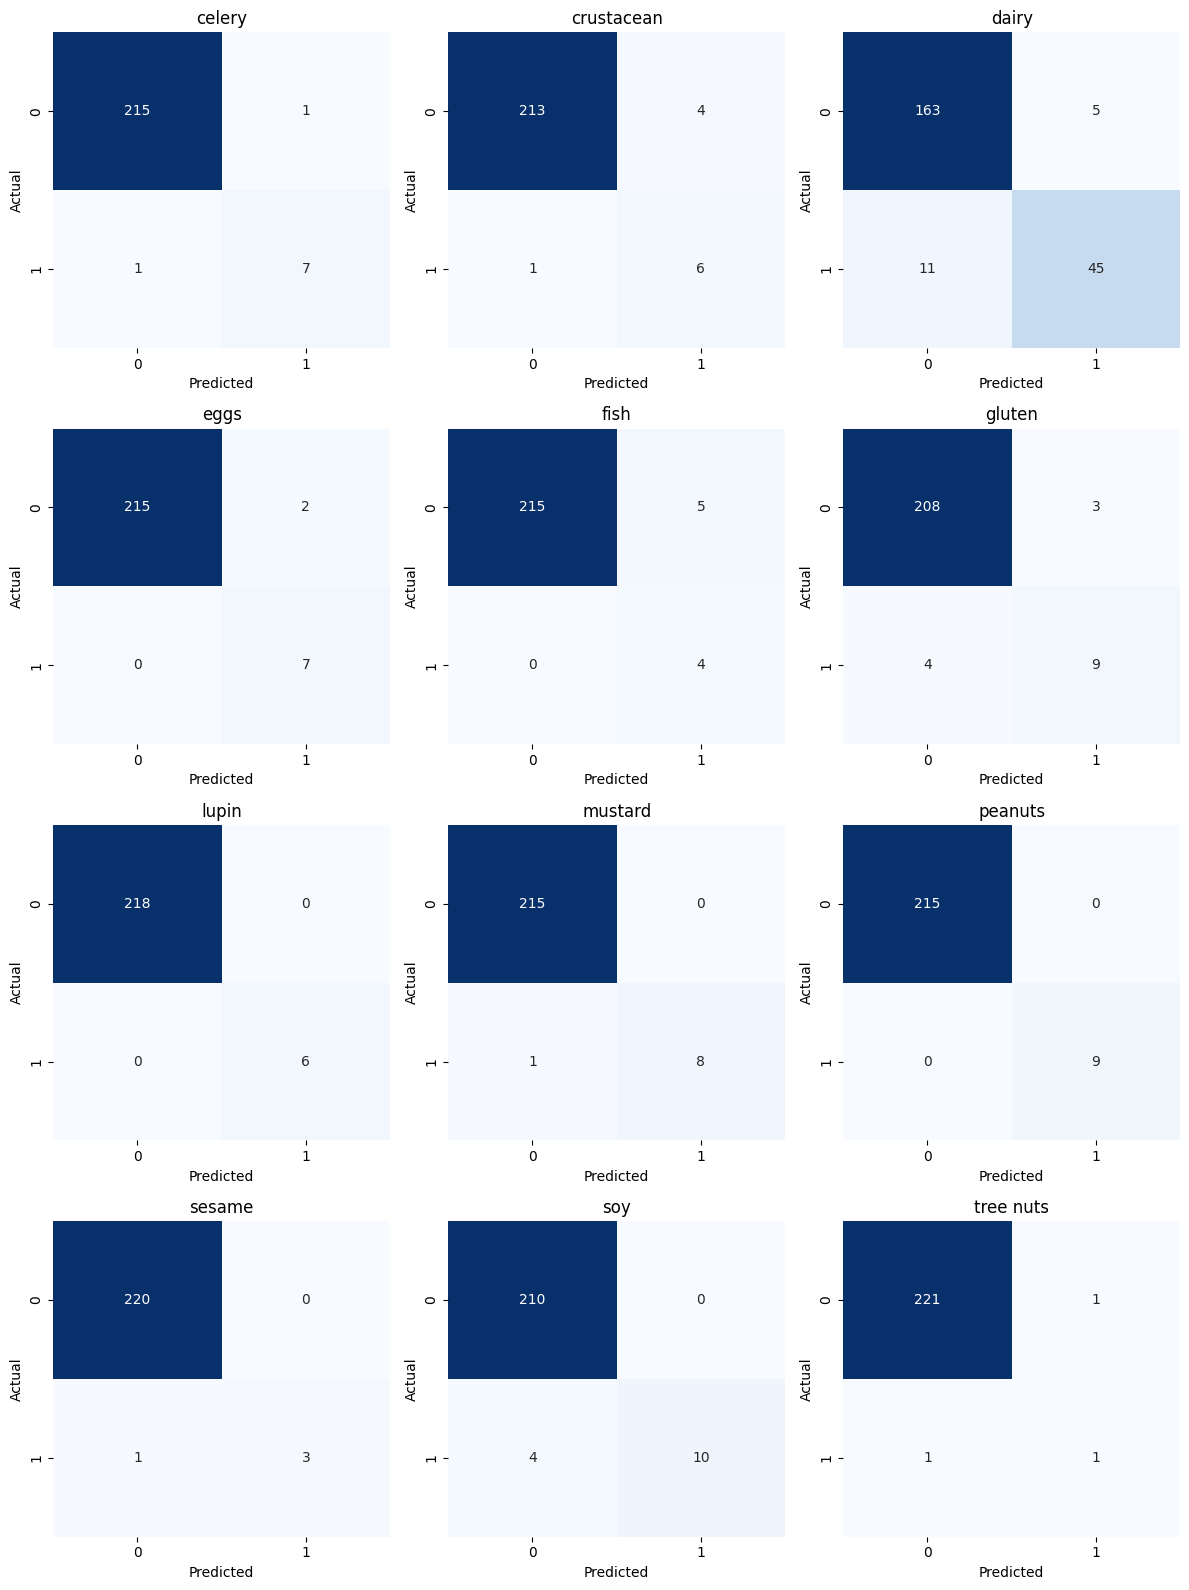

In [50]:

# Fitting the classifier on the training data
classifier.fit(X_train, y_train)

# Making predictions on the test set
predictions = classifier.predict(X_test)
proba = classifier.predict_proba(X_test)

# Evaluate the model, for example, using accuracy score
accuracy = classifier.score(X_test, y_test)
print("Accuracy:", accuracy)

y_pred = classifier.predict(X_test)

print("Hamming loss:", hamming_loss(y_test, y_pred))
print("Micro F1:", f1_score(y_test, y_pred, average='micro'))
print("Macro F1:", f1_score(y_test, y_pred, average='macro'))
print("Exact Match Ratio: ", np.all(y_pred == y_test, axis=1).mean())
print("01 Loss: ", np.any(y_test != y_pred, axis=1).mean())
print("Per-label report:\n", classification_report(y_test, y_pred, target_names=mlb.classes_))


print(mlb.classes_)

from sklearn.metrics import multilabel_confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cms = multilabel_confusion_matrix(y_test, y_pred)
print(cms.shape)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

labels = mlb.classes_ 

n_labels = len(labels)
cols = 3
rows = int(np.ceil(n_labels / cols))

fig, axes = plt.subplots(rows, cols, figsize=(12, rows * 4))

axes = axes.flatten()

for i, ax in enumerate(axes):
    if i < n_labels:
        sns.heatmap(
            cms[i],
            annot=True,
            fmt="d",
            cmap="Blues",
            cbar=False,
            ax=ax
        )
        ax.set_title(labels[i])
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
    else:
        ax.axis("off")

plt.tight_layout()
plt.show()


In [28]:
new_sentences = ["Salmon"]
new_sentence_tfidf = combined.transform(new_sentences)
probas = classifier.predict_proba(new_sentence_tfidf)

predicted_sentences = classifier.predict(new_sentence_tfidf)
proba_sentence = classifier.predict_proba(new_sentence_tfidf)
#print(predicted_sentences)
#print(mlb.classes_)

decoded = [mlb.classes_[i] for i, val in enumerate(predicted_sentences[0]) if (val == 1).any()]
print(decoded)
print(proba_sentence)



['fish']
[array([[0.943308, 0.056692]]), array([[0.96588531, 0.03411469]]), array([[0.92182556, 0.07817444]]), array([[0.94586628, 0.05413372]]), array([[0.04698641, 0.95301359]]), array([[0.94471076, 0.05528924]]), array([[0.97943328, 0.02056672]]), array([[0.97319063, 0.02680937]]), array([[0.97856357, 0.02143643]]), array([[0.98598953, 0.01401047]]), array([[0.85555302, 0.14444698]]), array([[0.93595476, 0.06404524]])]
